# ResNet-1D + MLP (GKR regression)

Uses preprocessed CSVs from `ProcessedRepositoryData`.

- **Train:** all sessions (T01–T03) for **SL01–SL05**, plus **T01–T02** for **SL06–SL07**.
- **Validate:** **T03** for **SL06–SL07**.

**Model:** EEG `(batch, channels, time)` → **ResNet-1D** (stem + 4 residual stages, channel widening, temporal downsampling) → **global average pool** → **MLP** → scalar angle (normalized like `y`).  
**Regularization:** dropout in residual blocks and MLP head, **AdamW** weight decay (L2 on weights), **gradient clipping**, **cosine LR** schedule.


In [1]:
import os

os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

from pathlib import Path

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt

_mps = getattr(torch.backends, 'mps', None)
device = torch.device(
    'cuda' if torch.cuda.is_available() else 'mps' if _mps and _mps.is_available() else 'cpu'
)
print('Using device:', device)


Using device: mps


In [2]:
# ----------------------------
# Load data + windows
# ----------------------------
# Train: SL01–SL05 all sessions; SL06–SL07 T01–T02. Val: SL06–SL07 T03.
# ----------------------------
import re

JOINT_COLS = ['GHR', 'GKR', 'GAR', 'GHL', 'GKL', 'GAL', 'PHR', 'PKR', 'PAR', 'PHL', 'PKL', 'PAL']
ANGLE_TO_PREDICT = 'GKR'
LABEL_COL = ANGLE_TO_PREDICT

# All session CSVs under ProcessedRepositoryData/<SLxx-Txx>/<SLxx-Txx>.csv
_base = Path.cwd()
DATA_DIR = _base / 'ProcessedRepositoryData'
if not DATA_DIR.is_dir():
    DATA_DIR = _base.parent / 'ProcessedRepositoryData'
if not DATA_DIR.is_dir():
    DATA_DIR = _base.parent / 'LSTM' / 'ProcessedRepositoryData'
if not DATA_DIR.is_dir():
    DATA_DIR = Path('/Users/anikaawasthi/Desktop/gait-decoding/LSTM/ProcessedRepositoryData')

parts = []
for csv_path in sorted(DATA_DIR.glob('*/*.csv')):
    name = csv_path.parent.name
    m = re.match(r'^(SL\d+)-(T\d+)$', name)
    if not m:
        continue
    d = pd.read_csv(csv_path)
    d['Subject'] = m.group(1)
    d['Session'] = m.group(2)
    parts.append(d)
df_all = pd.concat(parts, ignore_index=True).sort_values(['Subject', 'Session', 'timestep']).reset_index(drop=True)
df_all['Trial'] = df_all['Session']

skip_cols = {'timestep', 'conductor', 'Subject', 'Session', 'Trial'} | set(JOINT_COLS)
eeg_cols = [c for c in df_all.columns if c not in skip_cols]
n_channels = len(eeg_cols)

def create_windows(df, window_size=512, stride=256, eeg_channels=None, angle_column='hip_right_angle'):
    X_windows = []
    y_labels = []
    for (subject, trial), group in df.groupby(['Subject', 'Trial']):
        group = group.sort_values('timestep').reset_index(drop=True)
        if len(group) < window_size:
            continue
        eeg_data = group[eeg_channels].values
        angles = group[angle_column].values
        for start in range(0, len(group) - window_size, stride):
            end = start + window_size
            window = eeg_data[start:end].T
            label = angles[start + window_size // 2]
            X_windows.append(window)
            y_labels.append(label)
        print(f"  {subject}-{trial}: {len(range(0, len(group) - window_size, stride))} windows")
    return np.array(X_windows), np.array(y_labels)

window_size = 512
stride = 256
batch_size = 256

train_subjects_full = ['SL01', 'SL02', 'SL03', 'SL04', 'SL05']
train_subjects_partial = ['SL06', 'SL07']
train_sessions_partial = ['T01', 'T02']
val_subjects = ['SL06', 'SL07']
val_sessions = ['T03']

df_train = pd.concat([
    df_all[df_all['Subject'].isin(train_subjects_full)],
    df_all[(df_all['Subject'].isin(train_subjects_partial)) & (df_all['Session'].isin(train_sessions_partial))],
], ignore_index=True)
df_val = df_all[(df_all['Subject'].isin(val_subjects)) & (df_all['Session'].isin(val_sessions))].reset_index(drop=True)

print('Train:')
X_train, y_train = create_windows(df_train, window_size=window_size, stride=stride, eeg_channels=eeg_cols, angle_column=ANGLE_TO_PREDICT)
print(f"\nX_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

print('Val:')
X_val, y_val = create_windows(df_val, window_size=window_size, stride=stride, eeg_channels=eeg_cols, angle_column=ANGLE_TO_PREDICT)
print(f"\nX_val shape: {X_val.shape}")
print(f"y_val shape: {y_val.shape}")

print(f"NaN in X_train: {np.isnan(X_train).sum()}")
print(f"NaN in y_train: {np.isnan(y_train).sum()}")
print(f"NaN in X_val: {np.isnan(X_val).sum()}")
print(f"NaN in y_val: {np.isnan(y_val).sum()}")

for X in (X_train, X_val):
    X[:] = np.nan_to_num(np.asarray(X, dtype=np.float32), nan=0.0, posinf=0.0, neginf=0.0)

X_mean, X_std = X_train.mean(), X_train.std() + 1e-6
y_mean, y_std = y_train.mean(), y_train.std() + 1e-6
X_train_norm = ((X_train - X_mean) / X_std).astype(np.float32)
y_train_norm = ((y_train - y_mean) / y_std).astype(np.float32)
X_val_norm = ((X_val - X_mean) / X_std).astype(np.float32)
y_val_norm = ((y_val - y_mean) / y_std).astype(np.float32)

print(f"X normalized range: {X_train_norm.min():.2f} to {X_train_norm.max():.2f}")
print(f"y normalized range: {y_train_norm.min():.2f} to {y_train_norm.max():.2f}")

class EEGWindowDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(np.asarray(y).reshape(-1, 1)).float()
    def __len__(self):
        return len(self.X)
    def __getitem__(self, i):
        return self.X[i], self.y[i]

train_ds = EEGWindowDataset(X_train_norm, y_train_norm)
val_ds = EEGWindowDataset(X_val_norm, y_val_norm)
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
print('Train windows:', len(train_ds), 'Val windows:', len(val_ds), 'in_channels:', n_channels)



Train:
  SL01-T01: 535 windows
  SL01-T02: 535 windows
  SL01-T03: 536 windows
  SL02-T01: 536 windows
  SL02-T02: 517 windows
  SL02-T03: 525 windows
  SL03-T01: 536 windows
  SL03-T02: 521 windows
  SL03-T03: 527 windows
  SL04-T01: 534 windows
  SL04-T02: 520 windows
  SL04-T03: 512 windows
  SL05-T01: 536 windows
  SL05-T02: 536 windows
  SL05-T03: 508 windows
  SL06-T01: 536 windows
  SL06-T02: 520 windows
  SL07-T01: 536 windows
  SL07-T02: 512 windows

X_train shape: (10018, 64, 512)
y_train shape: (10018,)
Val:
  SL06-T03: 508 windows
  SL07-T03: 511 windows

X_val shape: (1019, 64, 512)
y_val shape: (1019,)
NaN in X_train: 6016
NaN in y_train: 0
NaN in X_val: 576
NaN in y_val: 0
X normalized range: -19.79 to 19.69
y normalized range: -3.43 to 1.13
Train windows: 10018 Val windows: 1019 in_channels: 64


In [3]:
# ----------------------------
# Model: ResNet-1D -> GAP -> MLP (angle regression)
# ----------------------------
# x: (B, C, T) — 1D conv along time; residual blocks with skip connections.

import torch
import torch.nn.functional as F


class ResidualBlock1d(nn.Module):
    """Pre-norm style bottleneck-friendly block: conv-bn-relu-drop-conv-bn + skip."""

    def __init__(self, in_ch: int, out_ch: int, stride: int = 1, kernel_size: int = 7, dropout: float = 0.15):
        super().__init__()
        pad = kernel_size // 2
        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel_size, stride=stride, padding=pad, bias=False)
        self.bn1 = nn.BatchNorm1d(out_ch)
        self.drop = nn.Dropout(dropout)
        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size, stride=1, padding=pad, bias=False)
        self.bn2 = nn.BatchNorm1d(out_ch)
        self.skip = nn.Identity()
        if stride != 1 or in_ch != out_ch:
            self.skip = nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm1d(out_ch),
            )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        identity = self.skip(x)
        out = self.conv1(x)
        out = F.relu(self.bn1(out), inplace=True)
        out = self.drop(out)
        out = self.bn2(self.conv2(out))
        return F.relu(out + identity, inplace=True)


class ResNet1DBackbone(nn.Module):
    """Stem + 4 stages with stride-2 downsampling between stages (strong capacity for 512 taps)."""

    def __init__(
        self,
        in_channels: int,
        stem_ch: int = 64,
        widths: tuple = (64, 128, 256, 384),
        blocks_per_stage: tuple = (2, 2, 2, 2),
        kernel_size: int = 7,
        dropout: float = 0.15,
    ):
        super().__init__()
        # Stem: large kernel, stride 2 (T: 512 -> 256)
        self.stem = nn.Sequential(
            nn.Conv1d(in_channels, stem_ch, kernel_size=15, stride=2, padding=7, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=3, stride=2, padding=1),
        )
        # After stem+pool: T ~= 128 (depends on padding; forward test not needed if we GAP)

        self.layer1 = self._make_stage(stem_ch, widths[0], blocks_per_stage[0], first_stride=1, k=kernel_size, drop=dropout)
        self.layer2 = self._make_stage(widths[0], widths[1], blocks_per_stage[1], first_stride=2, k=kernel_size, drop=dropout)
        self.layer3 = self._make_stage(widths[1], widths[2], blocks_per_stage[2], first_stride=2, k=kernel_size, drop=dropout)
        self.layer4 = self._make_stage(widths[2], widths[3], blocks_per_stage[3], first_stride=2, k=kernel_size, drop=dropout)
        self.out_ch = widths[3]

    def _make_stage(self, in_ch, out_ch, num_blocks, first_stride, k, drop):
        layers = [ResidualBlock1d(in_ch, out_ch, stride=first_stride, kernel_size=k, dropout=drop)]
        for _ in range(1, num_blocks):
            layers.append(ResidualBlock1d(out_ch, out_ch, stride=1, kernel_size=k, dropout=drop))
        return nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        return x.mean(dim=-1)


class ResNet1DRegressor(nn.Module):
    def __init__(
        self,
        in_channels: int,
        stem_ch: int = 64,
        widths: tuple = (64, 128, 256, 384),
        blocks_per_stage: tuple = (2, 2, 2, 2),
        head_hidden: tuple = (512, 256),
        backbone_drop: float = 0.15,
        head_dropout: tuple = (0.45, 0.35),
    ):
        super().__init__()
        self.backbone = ResNet1DBackbone(
            in_channels=in_channels,
            stem_ch=stem_ch,
            widths=widths,
            blocks_per_stage=blocks_per_stage,
            kernel_size=7,
            dropout=backbone_drop,
        )
        d = self.backbone.out_ch
        h1, h2 = head_hidden
        hd1, hd2 = head_dropout
        self.head = nn.Sequential(
            nn.Linear(d, h1),
            nn.ReLU(inplace=True),
            nn.Dropout(hd1),
            nn.Linear(h1, h2),
            nn.ReLU(inplace=True),
            nn.Dropout(hd2),
            nn.Linear(h2, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        z = self.backbone(x)
        return self.head(z)


def train_epoch(model, loader, optimizer, criterion, max_grad_norm: float = 1.0):
    model.train()
    total, n = 0.0, 0
    for X, y in loader:
        X = X.to(device)
        y = y.to(device)
        optimizer.zero_grad()
        y_pred = model(X)
        loss = criterion(y_pred, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        optimizer.step()
        total += loss.item()
        n += 1
    return total / max(1, n)


@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total, n = 0.0, 0
    for X, y in loader:
        X = X.to(device)
        y = y.to(device)
        y_pred = model(X)
        loss = criterion(y_pred, y)
        total += loss.item()
        n += 1
    return total / max(1, n)


In [4]:
# ----------------------------
# Train: AdamW + cosine LR + early stopping
# ----------------------------
n_epochs = 50
patience = 10

model = ResNet1DRegressor(
    in_channels=n_channels,
    stem_ch=64,
    widths=(64, 128, 256, 384),
    blocks_per_stage=(2, 2, 2, 2),
    head_hidden=(512, 256),
    backbone_drop=0.15,
    head_dropout=(0.45, 0.35),
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-2, betas=(0.9, 0.999))
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs, eta_min=1e-6)

best_val_loss = float('inf')
epochs_no_improve = 0
best_path = 'resnet1d_gkr_best.pth'

for epoch in range(1, n_epochs + 1):
    train_loss = train_epoch(model, train_loader, optimizer, criterion, max_grad_norm=1.0)
    val_loss = eval_epoch(model, val_loader, criterion)
    scheduler.step()
    lr_now = optimizer.param_groups[0]['lr']
    print(f'[Epoch {epoch:03d}] lr={lr_now:.2e}  train_loss={train_loss:.6f}  val_loss={val_loss:.6f}')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), best_path)
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f'Early stopping on val loss. Best val_loss={best_val_loss:.6f}')
            break

model.load_state_dict(torch.load(best_path, map_location=device))
final_val_loss = eval_epoch(model, val_loader, criterion)
print(f'Best checkpoint val loss (normalized targets): {final_val_loss:.6f}')


[Epoch 001] lr=3.00e-04  train_loss=1.033559  val_loss=1.151424
[Epoch 002] lr=2.99e-04  train_loss=1.015063  val_loss=1.317795
[Epoch 003] lr=2.97e-04  train_loss=0.997466  val_loss=47.907043
[Epoch 004] lr=2.95e-04  train_loss=1.001420  val_loss=3.219904
[Epoch 005] lr=2.93e-04  train_loss=1.001727  val_loss=1.321006
[Epoch 006] lr=2.90e-04  train_loss=0.998868  val_loss=2.720025
[Epoch 007] lr=2.86e-04  train_loss=1.001814  val_loss=1.083042
[Epoch 008] lr=2.82e-04  train_loss=1.006611  val_loss=1.077335
[Epoch 009] lr=2.77e-04  train_loss=0.993154  val_loss=0.976049
[Epoch 010] lr=2.71e-04  train_loss=0.989694  val_loss=1.413390
[Epoch 011] lr=2.66e-04  train_loss=0.993767  val_loss=0.985785
[Epoch 012] lr=2.59e-04  train_loss=1.000405  val_loss=1.004174
[Epoch 013] lr=2.53e-04  train_loss=0.994758  val_loss=1.020331
[Epoch 014] lr=2.46e-04  train_loss=0.988773  val_loss=0.972500
[Epoch 015] lr=2.38e-04  train_loss=0.978489  val_loss=0.967565
[Epoch 016] lr=2.31e-04  train_loss=0.9

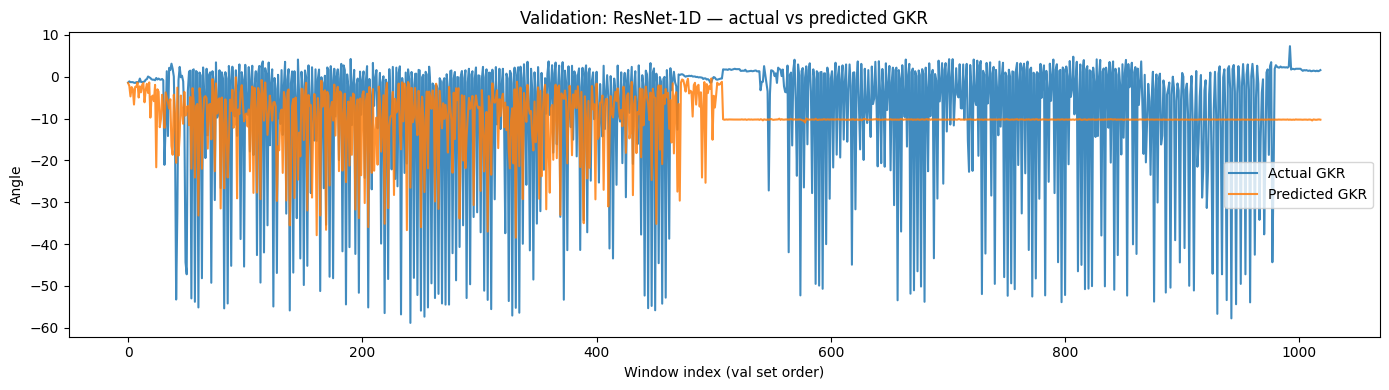

In [7]:
# ----------------------------
# Overlay: predicted vs actual GKR on validation (SL06–SL07, T03), degrees
# ----------------------------
@torch.no_grad()
def predict_normalized(model, loader):
    model.eval()
    preds, targets = [], []
    for X, y in loader:
        X = X.to(device)
        p = model(X).cpu().numpy().reshape(-1)
        preds.append(p)
        targets.append(y.numpy().reshape(-1))
    return np.concatenate(preds), np.concatenate(targets)


y_pred_norm, y_true_norm = predict_normalized(model, val_loader)
y_pred_deg = y_pred_norm * y_std + y_mean
y_true_deg = y_true_norm * y_std + y_mean

t = np.arange(len(y_true_deg))
plt.figure(figsize=(14, 4))
plt.plot(t, y_true_deg, label=f'Actual {LABEL_COL}', alpha=0.85)
plt.plot(t, y_pred_deg, label=f'Predicted {LABEL_COL}', alpha=0.85)
plt.xlabel('Window index (val set order)')
plt.ylabel('Angle')
plt.title('Validation: ResNet-1D — actual vs predicted GKR')
plt.legend()
plt.tight_layout()
plt.show()


### ResNet-1D diagnostics

**1. Saliency / Integrated Gradients** — Which parts of the input (time points) are most important for the model’s prediction?

**2. Activation maps** — mid-stage conv responses (feature maps after conv, before second BN+ReLU in the block).

**3. Filter visualization** — stem conv 1D kernels (sanity check on learned temporal patterns).

Same validation batch: **extreme** vs **near batch-mean** normalized target for side-by-side plots.


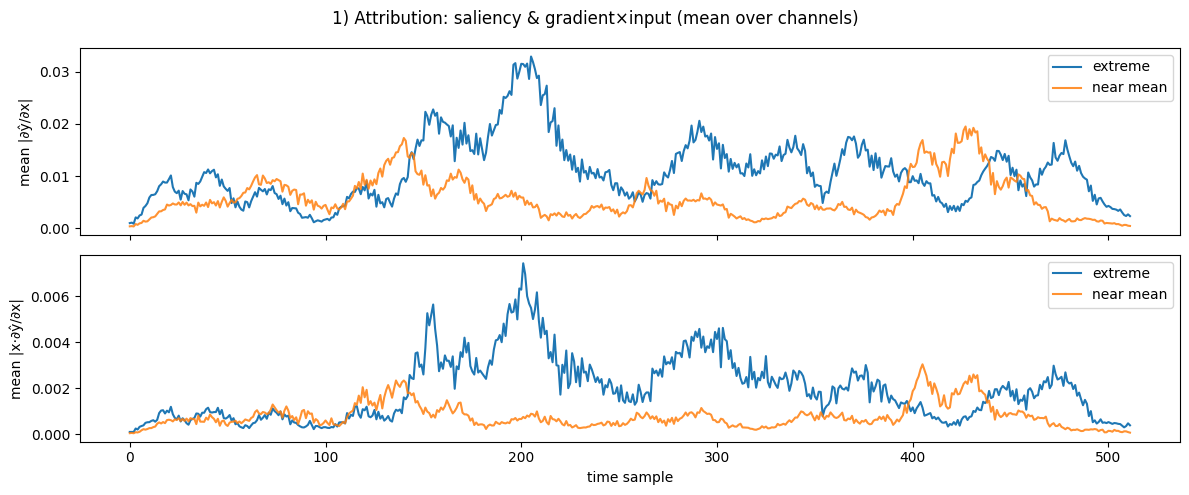

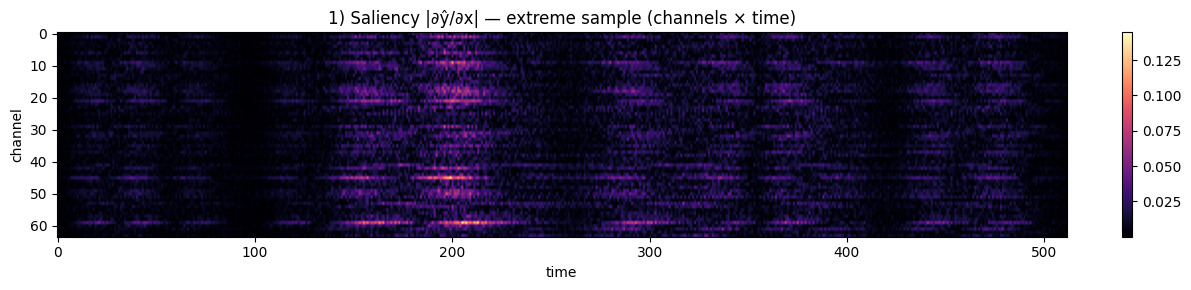

captum not installed — skip Integrated Gradients (`pip install captum`).


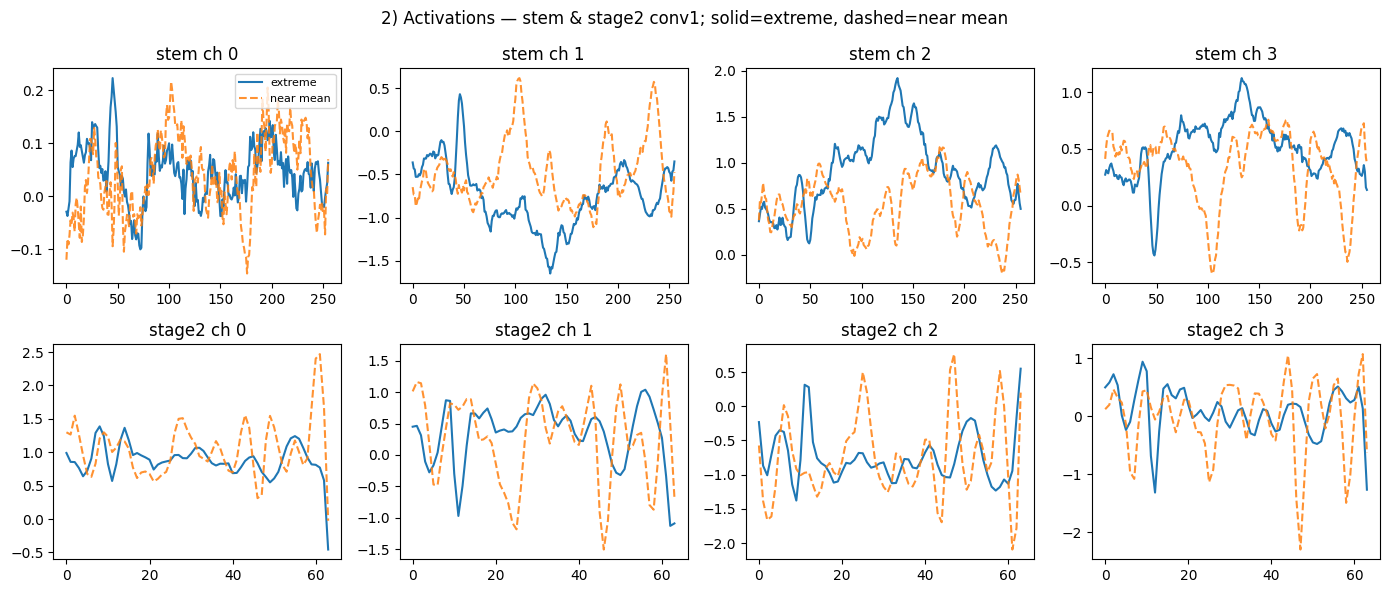

Stem conv weights: (64, 64, 15) (out, in, kernel_len)


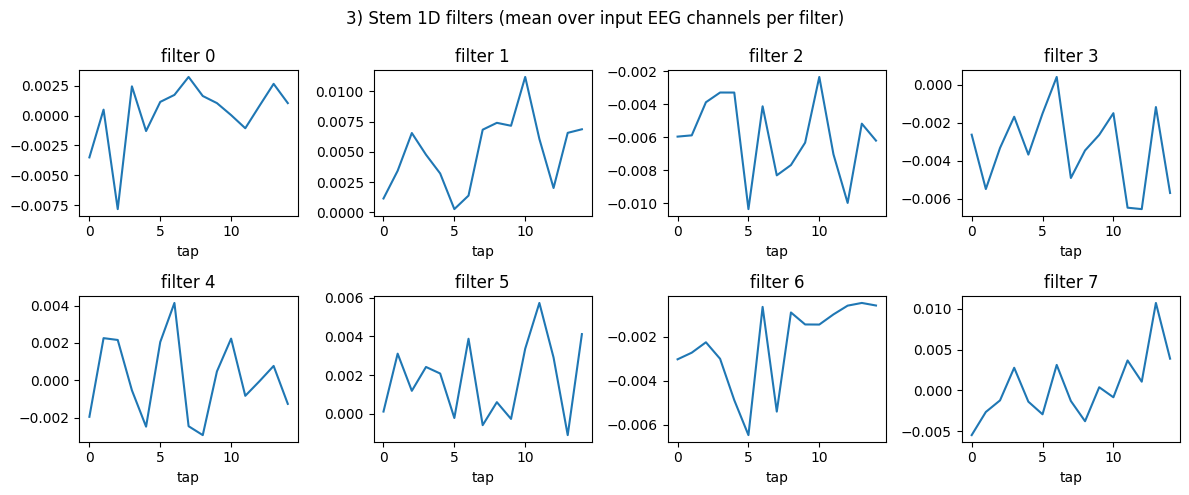

In [8]:
# ----------------------------
# ResNet visualization (1) saliency/IG → (2) activations → (3) stem filters
# ----------------------------
model.eval()

X_batch, y_batch = next(iter(val_loader))
y_flat = y_batch.squeeze(1)
dev = (y_flat - y_flat.mean()).abs()
i_ext = int(dev.argmax())
i_mid = int(dev.argmin())
x_ext = X_batch[i_ext : i_ext + 1].to(device).clone()
x_mid = X_batch[i_mid : i_mid + 1].to(device).clone()


def input_grad_attr(x_in):
    x_in = x_in.detach().clone().requires_grad_(True)
    model.zero_grad(set_to_none=True)
    out = model(x_in)
    out.backward()
    if x_in.grad is None:
        return None, None
    sal = x_in.grad.abs()
    gxinp = (x_in.detach() * x_in.grad).abs()
    return sal, gxinp


def run_activations(x):
    acts = {}

    def hook(name):
        def _fn(module, inp, out):
            acts[name] = out.detach()

        return _fn

    # Stem first conv; first conv of stage 2 (after one downsample)
    h0 = model.backbone.stem[0].register_forward_hook(hook('stem_conv'))
    h1 = model.backbone.layer2[0].conv1.register_forward_hook(hook('stage2_conv1'))
    with torch.no_grad():
        _ = model(x)
    h0.remove()
    h1.remove()
    return acts


# --- 1) Saliency + Integrated Gradients ---
g_ext, gx_ext = input_grad_attr(x_ext)
g_mid, gx_mid = input_grad_attr(x_mid)
t_axis = np.arange(x_ext.shape[-1])

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
fig.suptitle('1) Attribution: saliency & gradient×input (mean over channels)')
axes[0].plot(t_axis, g_ext[0].mean(0).cpu().numpy(), label='extreme')
axes[0].plot(t_axis, g_mid[0].mean(0).cpu().numpy(), alpha=0.85, label='near mean')
axes[0].set_ylabel('mean |∂ŷ/∂x|')
axes[0].legend()
axes[1].plot(t_axis, gx_ext[0].mean(0).cpu().numpy(), label='extreme')
axes[1].plot(t_axis, gx_mid[0].mean(0).cpu().numpy(), alpha=0.85, label='near mean')
axes[1].set_ylabel('mean |x·∂ŷ/∂x|')
axes[1].set_xlabel('time sample')
axes[1].legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 3))
im = ax.imshow(g_ext[0].cpu().numpy(), aspect='auto', cmap='magma')
ax.set_title('1) Saliency |∂ŷ/∂x| — extreme sample (channels × time)')
ax.set_ylabel('channel')
ax.set_xlabel('time')
plt.colorbar(im, ax=ax, fraction=0.035)
plt.tight_layout()
plt.show()

try:
    from captum.attr import IntegratedGradients

    bas = torch.zeros_like(x_ext)
    ig = IntegratedGradients(model)
    attr = ig.attribute(x_ext, baselines=bas, n_steps=32)
    attr = attr.abs().mean(dim=1).squeeze(0).cpu().numpy()
    plt.figure(figsize=(12, 3))
    plt.plot(attr)
    plt.title('1) Integrated Gradients (|attr|, mean over channels) — extreme sample')
    plt.xlabel('time')
    plt.tight_layout()
    plt.show()
except ImportError:
    print('captum not installed — skip Integrated Gradients (`pip install captum`).')
except Exception as e:
    print('Integrated Gradients skipped:', e)


# --- 2) Activation maps ---
with torch.no_grad():
    a_ext = run_activations(x_ext)
    a_mid = run_activations(x_mid)

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
fig.suptitle('2) Activations — stem & stage2 conv1; solid=extreme, dashed=near mean')
for j in range(4):
    axes[0, j].plot(a_ext['stem_conv'][0, j].cpu().numpy(), ls='-', label='extreme')
    axes[0, j].plot(a_mid['stem_conv'][0, j].cpu().numpy(), ls='--', alpha=0.85, label='near mean')
    axes[0, j].set_title(f'stem ch {j}')
    axes[1, j].plot(a_ext['stage2_conv1'][0, j].cpu().numpy(), ls='-')
    axes[1, j].plot(a_mid['stage2_conv1'][0, j].cpu().numpy(), ls='--', alpha=0.85)
    axes[1, j].set_title(f'stage2 ch {j}')
axes[0, 0].legend(fontsize=8)
plt.tight_layout()
plt.show()


# --- 3) Stem filter visualization ---
stem_conv = model.backbone.stem[0]
print('Stem conv weights:', tuple(stem_conv.weight.shape), '(out, in, kernel_len)')
W = stem_conv.weight.detach().cpu()
n_show = min(8, W.shape[0])
fig, axes = plt.subplots(2, 4, figsize=(12, 5))
fig.suptitle('3) Stem 1D filters (mean over input EEG channels per filter)')
for i in range(n_show):
    ax = axes.flat[i]
    ax.plot(W[i].mean(0).numpy())
    ax.set_title(f'filter {i}')
    ax.set_xlabel('tap')
plt.tight_layout()
plt.show()
